# ICP Forecasting — Exploratory Data Analysis
**MLOps LK-02 | Stage: Data Ingestion & EDA**

Exploratory analysis of the Indonesian Crude Price (ICP) monthly dataset.

## 0. Setup

In [8]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

print('Setup complete.')

Setup complete.


## 1. Load Dataset

In [9]:
dataset_path = project_root / 'data' / 'processed' / 'icp_dataset.csv'

df = pd.read_csv(dataset_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Rows: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Rows: 9
Columns: ['date', 'icp_price']


,date,icp_price
0,2019-01-01,56.55
1,2019-04-01,68.31
2,2019-05-01,68.07
3,2020-02-01,56.61
4,2020-03-01,34.23


## 2. Dataset Info & Statistics

In [10]:
print('=== DataFrame Info ===')
df.info()
print()
print('=== Descriptive Statistics ===')
df.describe()

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       9 non-null      datetime64[ns]
 1   icp_price  9 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 272.0 bytes

=== Descriptive Statistics ===


,date,icp_price
count,9,9.000000
mean,2020-08-14 05:20:00,55.636667
min,2019-01-01 00:00:00,20.660000
25%,2019-05-01 00:00:00,40.640000
50%,2020-03-01 00:00:00,56.610000
75%,2020-07-01 00:00:00,68.310000
max,2024-01-01 00:00:00,78.540000
std,NaN,20.029951


In [11]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDate range: {df["date"].min().date()} → {df["date"].max().date()}')

Missing values per column:
date         0
icp_price    0
dtype: int64

Date range: 2019-01-01 → 2024-01-01


## 3. ICP Price Trend

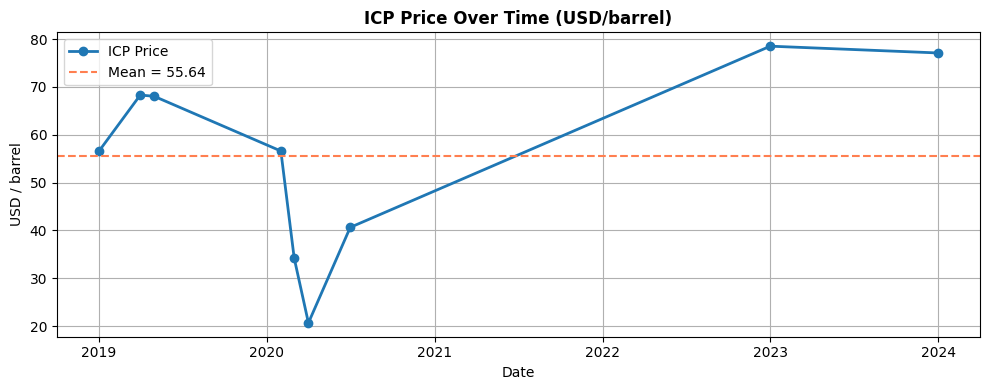

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df['date'], df['icp_price'], marker='o', linewidth=2, label='ICP Price')
plt.axhline(df['icp_price'].mean(), color='coral', linestyle='--',
            label=f'Mean = {df["icp_price"].mean():.2f}')
plt.title('ICP Price Over Time (USD/barrel)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('USD / barrel')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Price Distribution

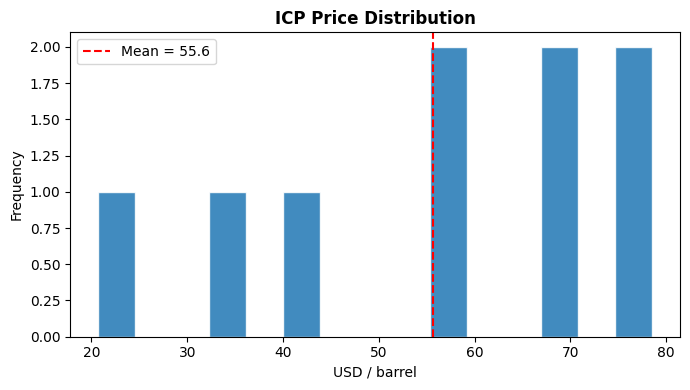

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(df['icp_price'], bins=15, edgecolor='white', alpha=0.85)
plt.axvline(df['icp_price'].mean(), color='red', linestyle='--',
            label=f'Mean = {df["icp_price"].mean():.1f}')
plt.title('ICP Price Distribution', fontweight='bold')
plt.xlabel('USD / barrel')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Year-over-Year Summary

In [14]:
df['year'] = df['date'].dt.year
yearly = df.groupby('year')['icp_price'].agg(['mean', 'min', 'max', 'count'])
yearly.columns = ['Mean', 'Min', 'Max', 'Months']
yearly.round(2)

,Mean,Min,Max,Months
year,,,,
2019,64.31,56.55,68.31,3
2020,38.03,20.66,56.61,4
2023,78.54,78.54,78.54,1
2024,77.12,77.12,77.12,1


---
**End of EDA Notebook — MLOps LK-02**